# Valid-route QAOA on IBM hardware

This notebook runs QAOA on real IBM Quantum hardware using a valid-route label encoding. The measured hardware bitstrings are not one-hot TSP assignments; they are labels. Every label is mapped to a valid fixed-start TSP tour, so every sampled output decodes to a valid tour by construction.

In [1]:
import importlib
import itertools
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as RuntimeEstimator, QiskitRuntimeService, SamplerV2 as RuntimeSampler

import utils

utils = importlib.reload(utils)
TSP = utils.TSP

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.grid": False,
    "figure.dpi": 130,
})


In [54]:
N_CITIES = 6
SEED = 6
START = 0

QAOA_REPS = 1
QAOA_MAXITER = 1
QAOA_INITIAL_POINT = np.array([0.35, 0.45])
SHOTS = 32
ESTIMATOR_PRECISION = 0.1

# This notebook is meant to run on IBM Quantum hardware.
RUN_REAL_BACKEND = True

N_VALID_TOURS = math.factorial(N_CITIES - 1)
LABEL_QUBITS = math.ceil(math.log2(N_VALID_TOURS))
LABEL_DIM = 2 ** LABEL_QUBITS

print(f"N_CITIES = {N_CITIES}")
print(f"Valid fixed-start tours = {N_VALID_TOURS:,}")
print(f"Label qubits = {LABEL_QUBITS}")
print(f"Label states = {LABEL_DIM:,}")
print(f"QAOA reps = {QAOA_REPS}")
print(f"QAOA maxiter = {QAOA_MAXITER}")
print(f"RUN_REAL_BACKEND = {RUN_REAL_BACKEND}")


N_CITIES = 6
Valid fixed-start tours = 120
Label qubits = 7
Label states = 128
QAOA reps = 1
QAOA maxiter = 1
RUN_REAL_BACKEND = True


In [57]:
def timed_solve(label, fn):
    t0 = time.perf_counter()
    tour, cost = fn()
    return {
        "method": label,
        "tour": tour,
        "cost": float(cost),
        "time_sec": time.perf_counter() - t0,
    }


def valid_fixed_start_routes(n_cities=N_CITIES, start=START):
    cities = [city for city in range(n_cities) if city != start]
    return [[start] + list(perm) + [start] for perm in itertools.permutations(cities)]


def pauli_z_string(mask, n_qubits):
    chars = ["I"] * n_qubits
    for q in range(n_qubits):
        if (mask >> q) & 1:
            chars[n_qubits - 1 - q] = "Z"
    return "".join(chars)


def diagonal_cost_operator(costs):
    costs = np.asarray(costs, dtype=float)
    n_qubits = int(np.log2(len(costs)))
    dim = len(costs)
    terms = []

    for mask in range(dim):
        coeff = 0.0
        for label, cost in enumerate(costs):
            parity = (mask & label).bit_count() % 2
            coeff += cost * (-1 if parity else 1)
        coeff /= dim

        if abs(coeff) > 1e-10:
            terms.append((pauli_z_string(mask, n_qubits), coeff))

    return SparsePauliOp.from_list(terms)


def clean_label_bits(bitstring, n_bits=LABEL_QUBITS):
    bits = bitstring.replace(" ", "")
    if len(bits) < n_bits:
        return bits.zfill(n_bits)
    if len(bits) > n_bits:
        return bits[-n_bits:]
    return bits


def label_to_tour(label, routes):
    return routes[label % len(routes)]


def sampler_counts(runtime_result):
    pub_result = runtime_result[0]
    data = pub_result.data
    for register_name in ("meas", "c", "cr", "creg"):
        register = getattr(data, register_name, None)
        if register is not None and hasattr(register, "get_counts"):
            return register.get_counts()
    for register_name in dir(data):
        if register_name.startswith("_"):
            continue
        register = getattr(data, register_name)
        if hasattr(register, "get_counts"):
            return register.get_counts()
    raise ValueError(f"Could not find counts in Runtime result data: {data}")


def summarize_label_counts(tsp, routes, counts):
    total = sum(counts.values())
    rows = []
    for raw_bitstring, shots in sorted(counts.items(), key=lambda item: item[1], reverse=True):
        bits = clean_label_bits(raw_bitstring)
        label = int(bits, 2)
        tour = label_to_tour(label, routes)
        rows.append({
            "raw_bits": raw_bitstring.replace(" ", ""),
            "label_bits": bits,
            "label": label,
            "shots": shots,
            "probability": shots / total,
            "valid": tsp.is_valid_tour(tour),
            "tour": " -> ".join(map(str, tour)),
            "cost": tsp.tour_cost(tour),
        })
    return pd.DataFrame(rows)


def objective_from_estimator(estimator, isa_ansatz, isa_operator, values_log):
    def objective(theta):
        theta = np.asarray(theta, dtype=float)
        job = estimator.run([(isa_ansatz, isa_operator, [theta])], precision=ESTIMATOR_PRECISION)
        result = job.result()[0]
        value = float(np.asarray(result.data.evs).reshape(-1)[0])
        values_log.append({"theta": theta.copy(), "energy": value})
        print(f"energy = {value:.6f}, theta = {theta}")
        return value
    return objective

tsp = TSP(n_locations=N_CITIES, seed=91)
coords = tsp.create_map()
distances = np.asarray(tsp.compute_distance_matrix(), dtype=float)

routes = valid_fixed_start_routes()
label_routes = [label_to_tour(label, routes) for label in range(LABEL_DIM)]
label_costs = np.array([tsp.tour_cost(tour) for tour in label_routes], dtype=float)
cost_operator = diagonal_cost_operator(label_costs)

print("Route labels are valid by construction:", all(tsp.is_valid_tour(tour) for tour in label_routes))
print("Cost-operator qubits:", cost_operator.num_qubits)
print("Cost-operator Pauli terms:", len(cost_operator))

classical_rows = []
greedy_row = timed_solve("Greedy", lambda: (lambda tour: (tour, tsp.tour_cost(tour)))(tsp.greedy_search(start=START)))
classical_rows.append(greedy_row)
two_opt_row = timed_solve("2-opt", lambda: tsp.two_opt(initial_tour=greedy_row["tour"]))
classical_rows.append(two_opt_row)
held_karp_row = timed_solve("Held-Karp", lambda: tsp.held_karp(start=START))
classical_rows.append(held_karp_row)

best_known_cost = held_karp_row["cost"]
comparison_rows = classical_rows.copy()
display(pd.DataFrame(classical_rows).assign(tour=lambda df: df["tour"].apply(lambda tour: " -> ".join(map(str, tour)))).round(5))


Route labels are valid by construction: True
Cost-operator qubits: 7
Cost-operator Pauli terms: 128


,method,tour,cost,time_sec
0,Greedy,0 -> 5 -> 3 -> 4 -> 1 -> 2 -> 0,295.57691,0.00002
1,2-opt,0 -> 1 -> 4 -> 5 -> 3 -> 2 -> 0,271.86453,0.00004
2,Held-Karp,0 -> 5 -> 3 -> 2 -> 4 -> 1 -> 0,253.48167,0.00012


## Real IBM backend QAOA

This is QAOA over valid route labels. The measured hardware string is a label, and every label maps to a valid tour.

In [58]:
if RUN_REAL_BACKEND:
    if os.environ.get("IBM_QUANTUM_TOKEN"):
        service = QiskitRuntimeService(channel="ibm_quantum", token=os.environ["IBM_QUANTUM_TOKEN"])
    else:
        service = QiskitRuntimeService()

    backend = service.least_busy(operational=True, min_num_qubits=100)
    print("Selected backend:", backend.name)
    print("Backend qubits:", backend.num_qubits)

    ansatz = QAOAAnsatz(cost_operator, reps=QAOA_REPS, flatten=True)
    pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)
    isa_ansatz = pass_manager.run(ansatz)
    isa_operator = cost_operator.apply_layout(isa_ansatz.layout)

    print("Logical label qubits:", ansatz.num_qubits)
    print("ISA ansatz qubits:", isa_ansatz.num_qubits)
    print("ISA operator qubits:", isa_operator.num_qubits)
    print("ISA gate counts:", dict(isa_ansatz.count_ops()))

    estimator = RuntimeEstimator(mode=backend)
    values_log = []
    objective = objective_from_estimator(estimator, isa_ansatz, isa_operator, values_log)

    t0 = time.perf_counter()
    optimizer_result = minimize(
        objective,
        x0=QAOA_INITIAL_POINT,
        method="COBYLA",
        options={"maxiter": QAOA_MAXITER},
    )
    hardware_time = time.perf_counter() - t0
    print("Optimizer result:", optimizer_result)

    optimal_ansatz = ansatz.assign_parameters(optimizer_result.x)
    optimal_ansatz.measure_all()
    isa_sampler_circuit = pass_manager.run(optimal_ansatz)

    sampler = RuntimeSampler(mode=backend)
    sample_job = sampler.run([isa_sampler_circuit], shots=SHOTS)
    sample_counts = sampler_counts(sample_job.result())
    hardware_samples = summarize_label_counts(tsp, routes, sample_counts)
    display(hardware_samples.head(12).round(5))

    print(f"Hardware valid fraction: {hardware_samples['valid'].mean():.4%}")
    best_sample = hardware_samples.sort_values(["cost", "shots"], ascending=[True, False]).iloc[0]
    comparison_rows.append({
        "method": "Valid HW QAOA",
        "tour": best_sample["tour"],
        "cost": float(best_sample["cost"]),
        "time_sec": hardware_time,
    })
else:
    backend = None
    hardware_samples = None
    print("Skipping real backend QAOA. Set RUN_REAL_BACKEND = True to submit.")


Selected backend: ibm_fez
Backend qubits: 156
Logical label qubits: 7
ISA ansatz qubits: 156
ISA operator qubits: 156
ISA gate counts: {'sx': 1172, 'rz': 1142, 'cz': 656}
energy = 297.822161, theta = [0.35 0.45]


C:\Users\Jogga\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\_lib\pyprima\common\preproc.py:68: UserWarning: COBYLA: Invalid MAXFUN; it should be at least num_vars + 2; it is set to 4
  warn(f'{solver}: Invalid MAXFUN; it should be at least {min_maxfun_str}; it is set to {maxfun}')


energy = 296.231769, theta = [1.35 0.45]
energy = 295.814307, theta = [1.35 1.45]
energy = 299.855185, theta = [2.31723337 1.70388899]
Optimizer result:  message: Return from COBYLA because the objective function has been evaluated MAXFUN times.
 success: False
  status: 3
     fun: 295.8143069335469
       x: [ 1.350e+00  1.450e+00]
    nfev: 4
   maxcv: 0.0


,raw_bits,label_bits,label,shots,probability,valid,tour,cost
0,1111111,1111111,127,3,0.09375,True,0 -> 1 -> 3 -> 2 -> 5 -> 4 -> 0,293.24251
1,0101100,0101100,44,2,0.06250,True,0 -> 2 -> 5 -> 3 -> 1 -> 4 -> 0,307.25627
2,0110010,0110010,50,2,0.06250,True,0 -> 3 -> 1 -> 4 -> 2 -> 5 -> 0,295.17709
3,0011011,0011011,27,2,0.06250,True,0 -> 2 -> 1 -> 4 -> 5 -> 3 -> 0,314.03978
4,0111111,0111111,63,2,0.06250,True,0 -> 3 -> 4 -> 2 -> 5 -> 1 -> 0,298.25882
5,0010011,0010011,19,2,0.06250,True,0 -> 1 -> 5 -> 2 -> 4 -> 3 -> 0,298.25882
6,1111100,1111100,124,1,0.03125,True,0 -> 1 -> 2 -> 5 -> 3 -> 4 -> 0,307.23392
7,1001010,1001010,74,1,0.03125,True,0 -> 4 -> 1 -> 3 -> 2 -> 5 -> 0,279.62850
8,1110111,1110111,119,1,0.03125,True,0 -> 5 -> 4 -> 3 -> 2 -> 1 -> 0,281.56315
9,1101010,1101010,106,1,0.03125,True,0 -> 5 -> 2 -> 4 -> 1 -> 3 -> 0,295.17709


Hardware valid fraction: 100.0000%


,method,tour,cost,gap_percent,time_sec
0,Greedy,0 -> 5 -> 3 -> 4 -> 1 -> 2 -> 0,295.57691,16.60682,0.00002
1,2-opt,0 -> 1 -> 4 -> 5 -> 3 -> 2 -> 0,271.86453,7.25214,0.00004
2,Held-Karp,0 -> 5 -> 3 -> 2 -> 4 -> 1 -> 0,253.48167,0.00000,0.00012
3,Valid HW QAOA,0 -> 5 -> 1 -> 4 -> 2 -> 3 -> 0,271.13322,6.96364,346.87553


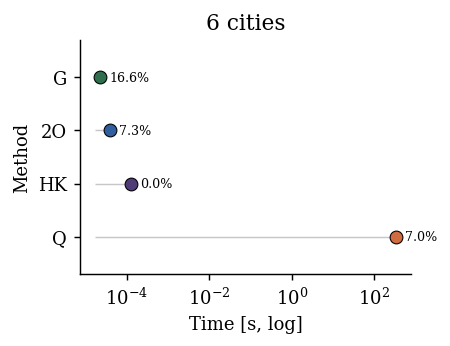

,label,method
0,G,Greedy
1,2O,2-opt
2,HK,Held-Karp
3,Q,Valid HW QAOA


In [59]:
comparison = pd.DataFrame(comparison_rows).copy()
comparison["gap_percent"] = 100 * (comparison["cost"] - best_known_cost) / best_known_cost
comparison["tour"] = comparison["tour"].apply(lambda tour: tour if isinstance(tour, str) else " -> ".join(map(str, tour)))
display(comparison[["method", "tour", "cost", "gap_percent", "time_sec"]].round(5))

label_map = {"Greedy": "G", "2-opt": "2O", "Held-Karp": "HK", "Valid HW QAOA": "Q"}
color_map = {"Greedy": "#2f6f4e", "2-opt": "#2f5f9f", "Held-Karp": "#4f3b78", "Valid HW QAOA": "#d06c3f"}
plot_df = comparison.copy()
plot_df["label"] = plot_df["method"].map(label_map)
plot_df["lane"] = np.arange(len(plot_df))[::-1]
plot_df["time_for_plot"] = plot_df["time_sec"].clip(lower=1e-8)
x0 = plot_df["time_for_plot"].min() * 0.75

fig, ax = plt.subplots(figsize=(3.35, 2.55), constrained_layout=True)
for _, row in plot_df.iterrows():
    ax.hlines(row["lane"], x0, row["time_for_plot"], color="0.78", linewidth=0.8, zorder=1)
    ax.scatter(row["time_for_plot"], row["lane"], s=50, color=color_map[row["method"]], edgecolor="black", linewidth=0.6, zorder=3)
    ax.annotate(f"{row['gap_percent']:.1f}%", (row["time_for_plot"], row["lane"]), xytext=(5, 0), textcoords="offset points", va="center", fontsize=7)

ax.set_xscale("log")
ax.set_yticks(plot_df["lane"], plot_df["label"])
ax.set_ylim(-0.7, len(plot_df) - 0.3)
ax.set_title(f"{N_CITIES} cities")
ax.set_xlabel("Time [s, log]")
ax.set_ylabel("Method")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

pd.DataFrame({"label": plot_df["label"], "method": plot_df["method"]})
